In [6]:
import os
import requests
import pandas as pd
import spotipy

from spotipy.oauth2 import SpotifyClientCredentials
from bs4 import BeautifulSoup

from collections import defaultdict
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from concurrent.futures import ThreadPoolExecutor, as_completed

In [11]:
# Set environment variables for Spotify API
os.environ['SPOTIPY_CLIENT_ID'] = 'xxx'
os.environ['SPOTIPY_CLIENT_SECRET'] = 'xxx'

# Authenticate with Spotify
spotify = spotipy.Spotify(auth_manager=SpotifyClientCredentials())

# Get Radiohead's audio features
artist = 'radiohead'
results = spotify.search(q=f'artist:{artist}', type='artist')
artist_id = results['artists']['items'][0]['id']

spotify_df = []
albums = spotify.artist_albums(artist_id, album_type='album')['items']
for album in albums:
    tracks = spotify.album_tracks(album['id'])['items']
    for track in tracks:
        audio_features = spotify.audio_features(track['id'])[0]
        audio_features['track_name'] = track['name']
        audio_features['album_name'] = album['name']
        audio_features['album_release_year'] = album['release_date'][:4]
        audio_features['album_img'] = album['images'][0]['url']
        spotify_df.append(audio_features)

spotify_df = pd.DataFrame(spotify_df)

In [12]:
# Filter out non-studio album
non_studio_albums = ['TKOL RMX 1234567', 'In Rainbows Disk 2', 'Com Lag: 2+2=5', 'I Might Be Wrong', 'OK Computer OKNOTOK 1997 2017']
spotify_df = spotify_df[~spotify_df['album_name'].isin(non_studio_albums)]

In [13]:
# Set Genius API token
token = 'VoiHulUkbE0d-9lk05LFg2IqwNrhRSAuMtkdYVlu8JMrYZ4-siaH-PB6ddX7878K'

# Function to get artists from Genius
def genius_get_artists(artist_name, n_results=10):
    baseURL = 'https://api.genius.com/search'
    headers = {'Authorization': f'Bearer {token}'}
    params = {'q': artist_name, 'per_page': n_results}
    
    response = requests.get(baseURL, headers=headers, params=params).json()
    hits = response['response']['hits']
    
    artists = [{'artist_id': hit['result']['primary_artist']['id'], 'artist_name': hit['result']['primary_artist']['name']} for hit in hits]
    return pd.DataFrame(artists).drop_duplicates()

genius_artists = genius_get_artists('radiohead')


In [14]:
# Get track lyric URLs from Genius
baseURL = f'https://api.genius.com/artists/{genius_artists.iloc[0]["artist_id"]}/songs'
track_lyric_urls = []
page = 1

while True:
    params = {'access_token': token, 'per_page': 50, 'page': page}
    response = requests.get(baseURL, params=params).json()['response']
    track_lyric_urls.extend(response['songs'])
    
    if response['next_page'] is not None:
        page = response['next_page']
    else:
        break

In [15]:
# Function to scrape lyrics from Genius
def lyric_scraper(url):
    try:
        page = requests.get(url)
        soup = BeautifulSoup(page.content, 'html.parser')
        lyrics = soup.find('div', class_='lyrics')
        lyrics = lyrics.get_text() if lyrics else ''
        
        # Clean lyrics
        lyrics = lyrics.lower()
        lyrics = ''.join([c if c.isalnum() else ' ' for c in lyrics])
        lyrics = ' '.join(lyrics.split())
        
        return lyrics
    except Exception as e:
        return None

# Concurrently get lyrics for each track
genius_df = []

def get_lyrics(track):
    lyrics = lyric_scraper(track['url'])
    return {
        'track_name': track['title'],
        'lyrics': lyrics
    }

with ThreadPoolExecutor(max_workers=10) as executor:
    future_to_track = {executor.submit(get_lyrics, track): track for track in track_lyric_urls}
    for future in as_completed(future_to_track):
        track = future_to_track[future]
        try:
            genius_df.append(future.result())
        except Exception as e:
            genius_df.append({
                'track_name': track['title'],
                'lyrics': None
            })

genius_df = pd.DataFrame(genius_df)

In [16]:
# Correct track names
track_name_corrections = {
    'Packt Like Sardines in a Crushd Tin Box': 'Packt Like Sardines in a Crushed Tin Box',
    'Weird Fishes / Arpeggi': 'Weird Fishes/ Arpeggi',
    'A Punchup at a Wedding': 'A Punch Up at a Wedding',
    'Dollars and Cents': 'Dollars & Cents',
    'Bullet Proof...I Wish I Was': 'Bullet Proof ... I Wish I Was'
}

genius_df['track_name'] = genius_df['track_name'].replace(track_name_corrections)
genius_df['track_name_join'] = genius_df['track_name'].str.replace('[^a-zA-Z0-9]', '', regex=True).str.lower()

genius_df = genius_df.drop_duplicates(subset=['track_name_join'])

In [17]:
# Merge Spotify and Genius dataframes
spotify_df['track_name_join'] = spotify_df['track_name'].str.replace('[^a-zA-Z0-9]', '', regex=True).str.lower()
track_df = spotify_df.merge(genius_df, on='track_name_join', how='left')

# Drop the duplicate 'track_name_y' column
track_df = track_df.drop(columns=['track_name_y'])

# Optionally, rename 'track_name_x' back to 'track_name'
track_df = track_df.rename(columns={'track_name_x': 'track_name'})

# Check the columns of the merged DataFrame
print(track_df.columns)


# Calculate valence and arrange tracks by valence
valence_df = track_df[['valence', 'track_name']].sort_values(by='valence').head(10)

Index(['danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness',
       'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo',
       'type', 'id', 'uri', 'track_href', 'analysis_url', 'duration_ms',
       'time_signature', 'track_name', 'album_name', 'album_release_year',
       'album_img', 'track_name_join', 'lyrics'],
      dtype='object')


In [22]:
import nltk
nltk.download('stopwords')
nltk.download('punkt')

# Sentiment analysis
stop_words = set(nltk.corpus.stopwords.words('english'))
sad_words = pd.read_csv('/Users/richienodollar/Spot/NRC-Emotion-Lexicon-Wordlevel-v0.92.txt', 
                        names=['word', 'emotion', 'association'], 
                        sep='\t')
sad_words = sad_words[(sad_words['emotion'] == 'sadness') & (sad_words['association'] == 1)]['word'].tolist()


def calculate_sentiment(lyrics):
    # Simple tokenization by splitting by spaces
    words = lyrics.lower().split()
    words = [word for word in words if word.isalpha()]  # Remove non-alphabetical characters (numbers, punctuation, etc.)
    words = [word for word in words if word not in stop_words]  # Remove stopwords
    sad_count = sum(1 for word in words if word in sad_words)  # Count sad words
    return sad_count / len(words) if len(words) > 0 else 0, len(words)

sentiments = []
for index, row in track_df.iterrows():
    if pd.notnull(row['lyrics']):
        pct_sad, word_count = calculate_sentiment(row['lyrics'])
    else:
        pct_sad, word_count = 0, 0
    sentiments.append({
        'track_name': row['track_name'],
        'pct_sad': pct_sad,
        'word_count': word_count
    })

sent_df = pd.DataFrame(sentiments)

# Merge sentiment data with track dataframe
track_df = track_df.merge(sent_df, on='track_name', how='left')
track_df['lyrical_density'] = track_df['word_count'] / track_df['duration_ms'] * 1000
track_df['gloom_index'] = 1 - ((1 - track_df['valence']) + (track_df['pct_sad'] * (1 + track_df['lyrical_density']))) / 2

# Rescale gloom index
scaler = MinMaxScaler((1, 100))
track_df['gloom_index'] = scaler.fit_transform(track_df[['gloom_index']])

['abandon', 'abandoned', 'abandonment', 'abduction', 'abortion', 'abortive', 'abscess', 'absence', 'absent', 'absentee', 'abuse', 'abysmal', 'abyss', 'accident', 'accursed', 'ache', 'aching', 'adder', 'adrift', 'adultery', 'adverse', 'adversity', 'afflict', 'affliction', 'affront', 'aftermath', 'aggravating', 'agony', 'ail', 'ailing', 'alcoholism', 'alienated', 'alienation', 'anathema', 'anchorage', 'anguish', 'animosity', 'annihilated', 'annihilation', 'annulment', 'anthrax', 'antisocial', 'anxiety', 'apathetic', 'apathy', 'apologize', 'appendicitis', 'arid', 'arraignment', 'arsenic', 'art', 'ashamed', 'ashes', 'assailant', 'assassin', 'assassination', 'atherosclerosis', 'atrocity', 'atrophy', 'attacking', 'attenuation', 'austere', 'autopsy', 'avalanche', 'awful', 'backwater', 'bacteria', 'bad', 'badly', 'bang', 'banish', 'banished', 'banishment', 'bankrupt', 'bankruptcy', 'banshee', 'barren', 'bastard', 'battered', 'battled', 'beating', 'beg', 'beggar', 'belittle', 'bereaved', 'berea

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/richienodollar/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     /Users/richienodollar/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


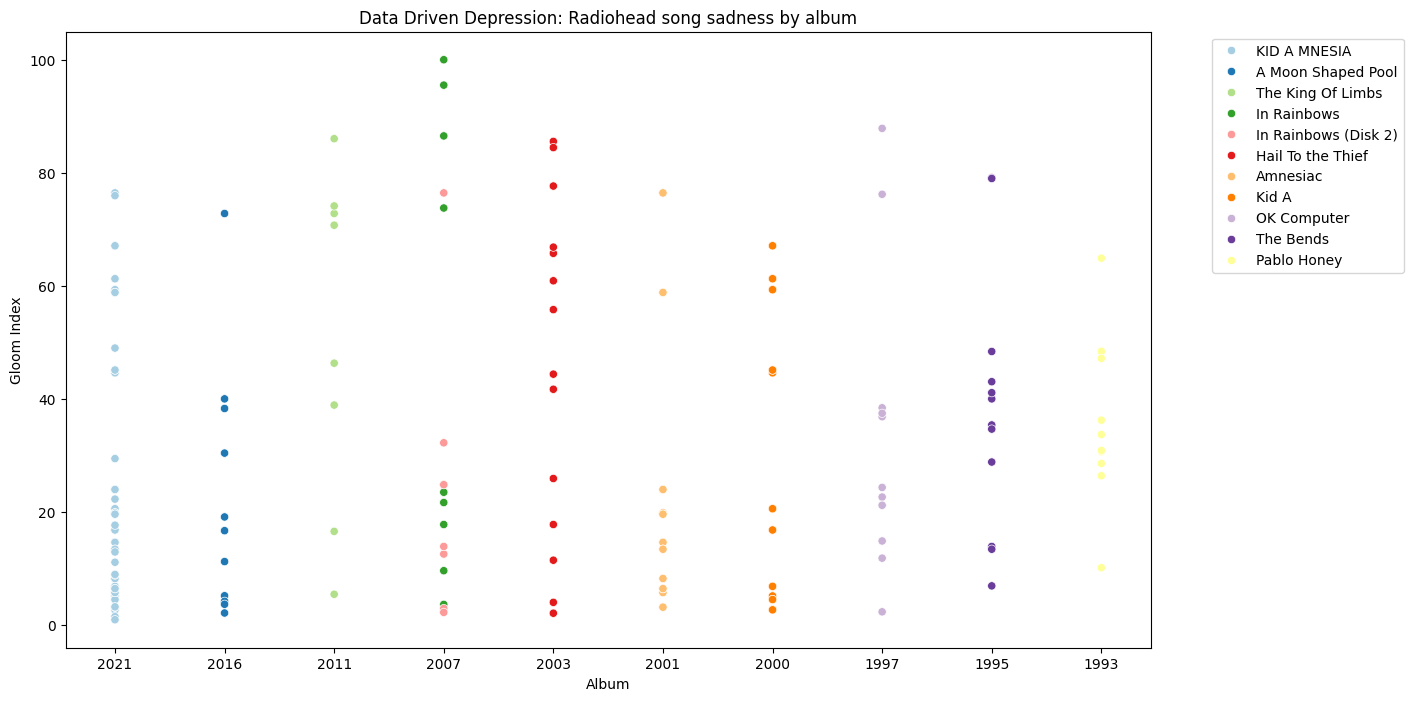

In [30]:
# Plotting
plt.figure(figsize=(14, 8))
sns.scatterplot(data=track_df, x='album_release_year', y='gloom_index', hue='album_name', palette='Paired')
plt.title('Data Driven Depression: Radiohead song sadness by album')
plt.xlabel('Album')
plt.ylabel('Gloom Index')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

In [36]:
!pip3 install plotly
import plotly.express as px

fig = px.scatter(
    track_df,
    x='album_name',
    y='gloom_index',
    color='album_name',  # Color by album name
    hover_data={
        'track_name': True,  # Show track name on hover
        'gloom_index': True  # Show gloom index on hover
    },
    labels={
        'album_release_year': 'Album Release Year',
        'gloom_index': 'Gloom Index',
        'track_name': 'Track Name',
    },
    title='Data Driven Depression: Radiohead song sadness'
)

# Show the plot
fig.show()